In [ ]:

# ==============================================================
# Importación de todas las librerías del proyecto
# ==============================================================

# --- Manejo de datos ---
import pandas as pd
import numpy as np
from pathlib import Path

# --- Visualización ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns


# --- Estadística y preprocesamiento ---
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)


# --- Configuración general de gráficas ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [3]:
# ==============================================================
# Descarga del dataset desde la BTS (fuente oficial)
#
# El dataset proviene del Bureau of Transportation Statistics
# (BTS) del gobierno de EE.UU. Contiene datos de rendimiento
# en tiempo real de aerolíneas comerciales: vuelos, retrasos,
# cancelaciones y causas — de acceso público y gratuito.
#
# Para el proyecto usamos el dataset del año 2022 (Junio a Diciembre)
# en formato ZIP pre-empaquetado por la BTS.
# Descargamos y descomprimimos directamente desde Colab.
# ==============================================================

import zipfile
import io
import requests

# Patrón de URL oficial de la BTS para descargar datos mensuales
base_url = 'https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip'

meses = range(6, 13)  # Enero a Diciembre
year = 2022

dfs = []
print(f'Descargando datos de vuelos del año {year}...')

for mes in meses:
    url = base_url.format(year=year, month=mes)
    print(f'   Mes {mes:02d}/{year}...', end=' ')
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            csv_name = [f for f in z.namelist() if f.endswith('.csv') and not f.startswith('__')][0]
            with z.open(csv_name) as f:
                df_mes = pd.read_csv(f, low_memory=False)
                dfs.append(df_mes)
        print(f'✓ ({len(df_mes):,} filas)')
    except Exception as e:
        
        
        print(f'✗ Error: {e}')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\n Dataset completo: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')

Descargando datos de vuelos del año 2022...
   Mes 06/2022... 

✓ (577,283 filas)
   Mes 07/2022... ✓ (594,957 filas)
   Mes 08/2022... ✓ (589,810 filas)
   Mes 09/2022... ✓ (557,494 filas)
   Mes 10/2022... ✓ (572,287 filas)
   Mes 11/2022... ✓ (546,410 filas)
   Mes 12/2022... ✓ (557,095 filas)

 Dataset completo: 3,995,336 filas × 110 columnas


In [4]:
# ==============================================================
# Selección de variables relevantes
#
# El dataset original tiene ~100 columnas. Selecciono solo
# las necesarias para el proyecto.
# ==============================================================

columnas = [
    # --- FECHA ---
    'FlightDate',          # Fecha del vuelo (tipo: fecha)
    'Month',               # Mes (tipo: ordinal)
    'DayOfWeek',           # Día de la semana 1=Lunes … 7=Dom (tipo: ordinal)

    # --- NOMINALES ---
    'Reporting_Airline',   # Código de aerolínea (tipo: nominal)
    'Origin',              # Aeropuerto de origen (tipo: nominal)
    'Dest',                # Aeropuerto de destino (tipo: nominal)
    'OriginStateName',     # Estado de origen (tipo: nominal)
    'DestStateName',       # Estado de destino (tipo: nominal)

    # --- CONTINUAS ---
    'DepDelay',            # Minutos de retraso en salida (tipo: continua)
    'ArrDelay',            # Minutos de retraso en llegada (tipo: continua)
    'Distance',            # Distancia del vuelo en millas (tipo: continua)
    'AirTime',             # Tiempo en el aire en minutos (tipo: continua)
    'CarrierDelay',        # Retraso atribuido a la aerolínea (tipo: continua)
    'WeatherDelay',        # Retraso por clima (tipo: continua)
    'NASDelay',            # Retraso por sistema aéreo nacional (tipo: continua)

    # --- DISCRETA ---
    'Flight_Number_Reporting_Airline',  # Número de vuelo (tipo: discreta)

    # --- BINARIAS ---
    'Cancelled',           # ¿Fue cancelado? 1=Sí, 0=No (tipo: binaria)
    'Diverted',            # ¿Fue desviado? 1=Sí, 0=No (tipo: binaria)
]

# Filtrar solo columnas que existan en el dataset
columnas_disponibles = [c for c in columnas if c in df_raw.columns]
df = df_raw[columnas_disponibles].copy()

# Crear variable binaria objetivo: ¿Hubo retraso significativo? (>15 min)
# Esto es el estándar de la FAA para considerar un vuelo "retrasado"
df['Delayed'] = (df['ArrDelay'] > 15).astype(int)

print('Variables seleccionadas y sus tipos:')
print(df.dtypes)
print(f'\nForma del dataset: {df.shape}')

Variables seleccionadas y sus tipos:
FlightDate                             str
Month                                int64
DayOfWeek                            int64
Reporting_Airline                      str
Origin                                 str
Dest                                   str
OriginStateName                        str
DestStateName                          str
DepDelay                           float64
ArrDelay                           float64
Distance                           float64
AirTime                            float64
CarrierDelay                       float64
WeatherDelay                       float64
NASDelay                           float64
Flight_Number_Reporting_Airline      int64
Cancelled                          float64
Diverted                           float64
Delayed                              int64
dtype: object

Forma del dataset: (3995336, 19)


---
# PARTE 1 — Análisis Exploratorio de Datos (EDA)

## 1.1 Contexto del Dataset

**Origen de los datos:** Bureau of Transportation Statistics (BTS), agencia oficial del gobierno de EE.UU. bajo el Departamento de Transporte (DOT). Recopila datos de todas las aerolíneas certificadas que operan en territorio estadounidense.

**Situación problema:** Los retrasos en vuelos generan pérdidas económicas estimadas en miles de millones de dólares anuales y afectan la experiencia de millones de pasajeros. Identificar los factores que determinan si un vuelo se retrasará permite a aerolíneas y aeropuertos tomar decisiones preventivas.

**Preguntas a responder con el EDA:**
1. ¿Qué aerolíneas tienen mayor tasa de retrasos?
2. ¿En qué meses y días de la semana se concentran más retrasos?
3. ¿Cuál es la causa principal de los retrasos?
4. ¿Existe relación entre la distancia del vuelo y el retraso?

## 1.2 Variables del Dataset

| Variable | Tipo | Unidad / Descripción |
|---|---|---|
| `FlightDate` | Fecha | Fecha del vuelo (YYYY-MM-DD) |
| `Month` | Ordinal | Mes (1=Enero … 12=Diciembre) |
| `DayOfWeek` | Ordinal | Día (1=Lunes … 7=Domingo) |
| `Reporting_Airline` | Nominal | Código IATA de la aerolínea |
| `Origin` / `Dest` | Nominal | Código del aeropuerto |
| `OriginStateName` / `DestStateName` | Nominal | Nombre del estado |
| `DepDelay` | Continua | Minutos de retraso en salida |
| `ArrDelay` | Continua | Minutos de retraso en llegada |
| `Distance` | Continua | Millas de distancia del vuelo |
| `AirTime` | Continua | Minutos en el aire |
| `CarrierDelay` / `WeatherDelay` / `NASDelay` | Continua | Minutos de retraso por causa |
| `Flight_Number_Reporting_Airline` | Discreta | Número de vuelo |
| `Cancelled` | Binaria | 0=No cancelado, 1=Cancelado |
| `Diverted` | Binaria | 0=No desviado, 1=Desviado |
| `Delayed` | Binaria | **Variable objetivo**: 1 si ArrDelay > 15 min |

In [5]:
# ==============================================================
# Tratamiento Preliminar: Exploración inicial
# Revisamos dimensiones, tipos de datos, valores nulos y
# duplicados para entender el estado del dataset.
# ==============================================================

print('='*60)
print('EXPLORACIÓN INICIAL DEL DATASET')
print('='*60)

print(f'\n Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')

print('\n Primeras 5 filas:')
display(df.head())

print('\n Tipos de datos:')
display(df.dtypes.to_frame('Tipo'))

print('\n Valores nulos por columna:')
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
display(pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos}).query('Nulos > 0'))

print(f'\n Filas duplicadas: {df.duplicated().sum():,}')

EXPLORACIÓN INICIAL DEL DATASET

 Dimensiones: 3,995,336 filas × 19 columnas

 Primeras 5 filas:


,FlightDate,Month,DayOfWeek,Reporting_Airline,Origin,Dest,OriginStateName,DestStateName,DepDelay,ArrDelay,Distance,AirTime,CarrierDelay,WeatherDelay,NASDelay,Flight_Number_Reporting_Airline,Cancelled,Diverted,Delayed
0,2022-06-27,6,1,OH,SBN,CLT,Indiana,North Carolina,10.0,12.0,534.0,72.0,NaN,NaN,NaN,5399,0.0,0.0,0
1,2022-06-28,6,2,OH,SBN,CLT,Indiana,North Carolina,-4.0,-17.0,534.0,75.0,NaN,NaN,NaN,5399,0.0,0.0,0
2,2022-06-29,6,3,OH,SBN,CLT,Indiana,North Carolina,-9.0,-15.0,534.0,72.0,NaN,NaN,NaN,5399,0.0,0.0,0
3,2022-06-30,6,4,OH,SBN,CLT,Indiana,North Carolina,-3.0,-14.0,534.0,73.0,NaN,NaN,NaN,5399,0.0,0.0,0
4,2022-06-01,6,3,OH,CLT,PIA,North Carolina,Illinois,3.0,-8.0,607.0,88.0,NaN,NaN,NaN,5400,0.0,0.0,0



 Tipos de datos:


,Tipo
FlightDate,str
Month,int64
DayOfWeek,int64
Reporting_Airline,str
Origin,str
Dest,str
OriginStateName,str
DestStateName,str
DepDelay,float64
ArrDelay,float64



 Valores nulos por columna:


,Nulos,% Nulos
DepDelay,90838,2.27
ArrDelay,102781,2.57
AirTime,102781,2.57
CarrierDelay,3168480,79.30
WeatherDelay,3168480,79.30
NASDelay,3168480,79.30



 Filas duplicadas: 0


In [6]:
# ==============================================================
# Tratamiento Preliminar: Limpieza de datos
#
# Los nulos en las columnas de causa de retraso (CarrierDelay,
# WeatherDelay, etc.) corresponden a vuelos sin retraso (el
# valor real es 0). Las imputamos con 0.
# Eliminamos filas sin ArrDelay ya que es nuestra variable clave.
# ==============================================================

# Convertir FlightDate a tipo datetime
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

# Imputar causas de retraso: NaN → 0 (sin retraso por esa causa)
cols_delay = ['CarrierDelay', 'WeatherDelay', 'NASDelay']
for col in cols_delay:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Eliminar filas donde no hay información de ArrDelay
# (vuelos cancelados no tienen ArrDelay — los excluimos del análisis
# de retraso pero los conservamos para el EDA general)
df_model = df.dropna(subset=['ArrDelay', 'DepDelay', 'Distance', 'AirTime']).copy()

# Recalcular Delayed con el subset limpio
df_model['Delayed'] = (df_model['ArrDelay'] > 15).astype(int)

# Eliminar outliers extremos en ArrDelay
df_model = df_model[df_model['ArrDelay'].between(-120, 480)]

print(f' Dataset después de limpieza: {df_model.shape[0]:,} filas')
print(f'   Nulos restantes: {df_model.isnull().sum().sum()}')

 Dataset después de limpieza: 3,885,432 filas
   Nulos restantes: 0


In [7]:
# ==============================================================
# Estadísticas descriptivas de variables continuas
# El método .describe() nos da media, desviación estándar,
# cuartiles y valores extremos de cada variable numérica.
# ==============================================================

print(' Estadísticas descriptivas — variables numéricas:')
cols_num = ['ArrDelay', 'DepDelay', 'Distance', 'AirTime', 'CarrierDelay', 'WeatherDelay']
cols_num = [c for c in cols_num if c in df_model.columns]
display(df_model[cols_num].describe().round(2))

 Estadísticas descriptivas — variables numéricas:


,ArrDelay,DepDelay,Distance,AirTime,CarrierDelay,WeatherDelay
count,3885432.00,3885432.00,3885432.00,3885432.00,3885432.00,3885432.00
mean,5.93,11.27,814.08,111.93,4.67,0.68
std,40.59,38.10,598.74,70.03,21.72,9.25
min,-99.00,-96.00,31.00,8.00,0.00,0.00
25%,-14.00,-5.00,379.00,61.00,0.00,0.00
50%,-5.00,-1.00,653.00,94.00,0.00,0.00
75%,10.00,10.00,1047.00,141.00,0.00,0.00
max,480.00,519.00,5095.00,697.00,480.00,480.00


In [8]:
# ==============================================================
# Descripción de variables categóricas
# Contamos categorías únicas y las más frecuentes.
# ==============================================================

print(' Variables categóricas — valores únicos y más frecuentes:\n')
cols_cat = ['Reporting_Airline', 'Origin', 'Dest', 'OriginStateName']
cols_cat = [c for c in cols_cat if c in df_model.columns]

for col in cols_cat:
    n_unique = df_model[col].nunique()
    top3 = df_model[col].value_counts().head(3).to_dict()
    print(f'  {col}: {n_unique} categorías únicas')
    print(f'    Top 3: {top3}\n')

 Variables categóricas — valores únicos y más frecuentes:

  Reporting_Airline: 17 categorías únicas
    Top 3: {'WN': 774653, 'DL': 526955, 'AA': 511934}

  Origin: 368 categorías únicas
    Top 3: {'ATL': 185429, 'DEN': 161360, 'DFW': 160110}

  Dest: 369 categorías únicas
    Top 3: {'ATL': 185406, 'DEN': 160908, 'DFW': 159479}

  OriginStateName: 53 categorías únicas
    Top 3: {'California': 434388, 'Texas': 410696, 'Florida': 312124}



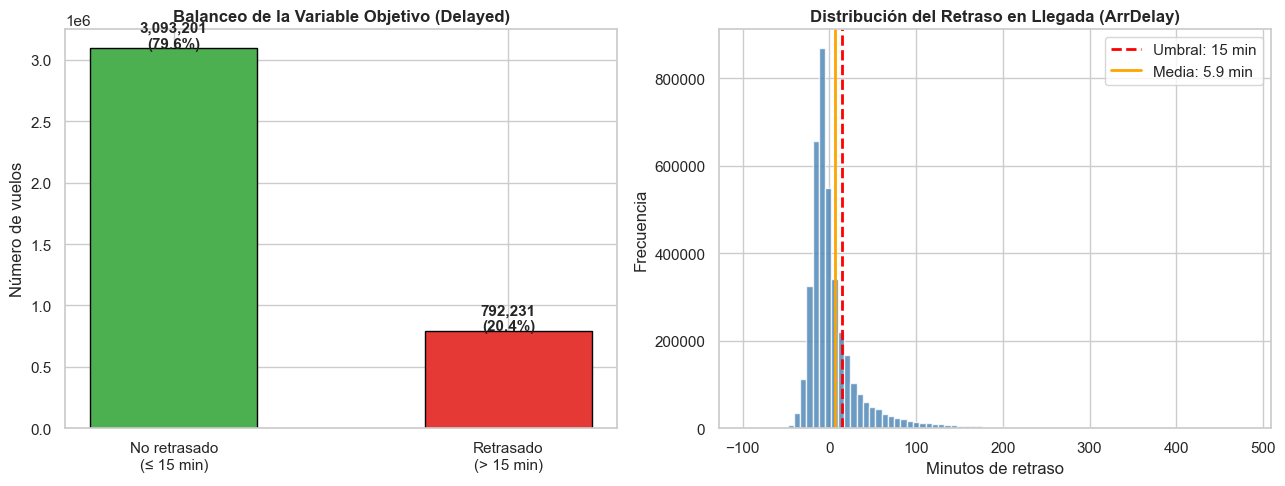


Prueba estadística sobre la variable objetivo:
  Media de ArrDelay: 5.93 min
  Mediana de ArrDelay: -5.00 min
  Proporción de vuelos retrasados: 20.4%

  Test de normalidad (KS) sobre ArrDelay:
  Estadístico=0.5567, p-valor=0.000000
  Conclusión: La distribución NO es normal (p < 0.05)


In [9]:
# ==============================================================
# Variable objetivo: análisis del balanceo
#
# Antes de modelar, es crucial entender si la variable binaria
# objetivo está balanceada o no.
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gráfica de barras: conteo de vuelos retrasados vs no retrasados ---
conteo = df_model['Delayed'].value_counts()
etiquetas = ['No retrasado\n(≤ 15 min)', 'Retrasado\n(> 15 min)']
colores = ['#4CAF50', '#E53935']
axes[0].bar(etiquetas, conteo.values, color=colores, edgecolor='black', width=0.5)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5000, f'{v:,}\n({v/len(df_model)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Balanceo de la Variable Objetivo (Delayed)', fontweight='bold')
axes[0].set_ylabel('Número de vuelos')

# --- Distribución del retraso en llegada ---
axes[1].hist(df_model['ArrDelay'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(15, color='red', linestyle='--', linewidth=2, label='Umbral: 15 min')
axes[1].axvline(df_model['ArrDelay'].mean(), color='orange', linestyle='-', linewidth=2,
                label=f'Media: {df_model["ArrDelay"].mean():.1f} min')
axes[1].set_title('Distribución del Retraso en Llegada (ArrDelay)', fontweight='bold')
axes[1].set_xlabel('Minutos de retraso')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nPrueba estadística sobre la variable objetivo:')
print(f'  Media de ArrDelay: {df_model["ArrDelay"].mean():.2f} min')
print(f'  Mediana de ArrDelay: {df_model["ArrDelay"].median():.2f} min')
print(f'  Proporción de vuelos retrasados: {df_model["Delayed"].mean()*100:.1f}%')

# Prueba de normalidad (Shapiro en muestra pequeña, KS para datasets grandes)
stat, p = stats.kstest(df_model['ArrDelay'].sample(1000, random_state=42), 'norm')
print(f'\n  Test de normalidad (KS) sobre ArrDelay:')
print(f'  Estadístico={stat:.4f}, p-valor={p:.6f}')
print(f'  Conclusión: La distribución NO es normal (p < 0.05)' if p < 0.05 else 'es normal (p >= 0.05)')

Distribución de la variable objetivo: aproximadamente 21% de los vuelos presentaron retraso significativo (>15 min).
Adicional con la prueba de normalidad (ks) podemos concluir que la distribucion de la variable ArrDelay no es una distribucion normal.

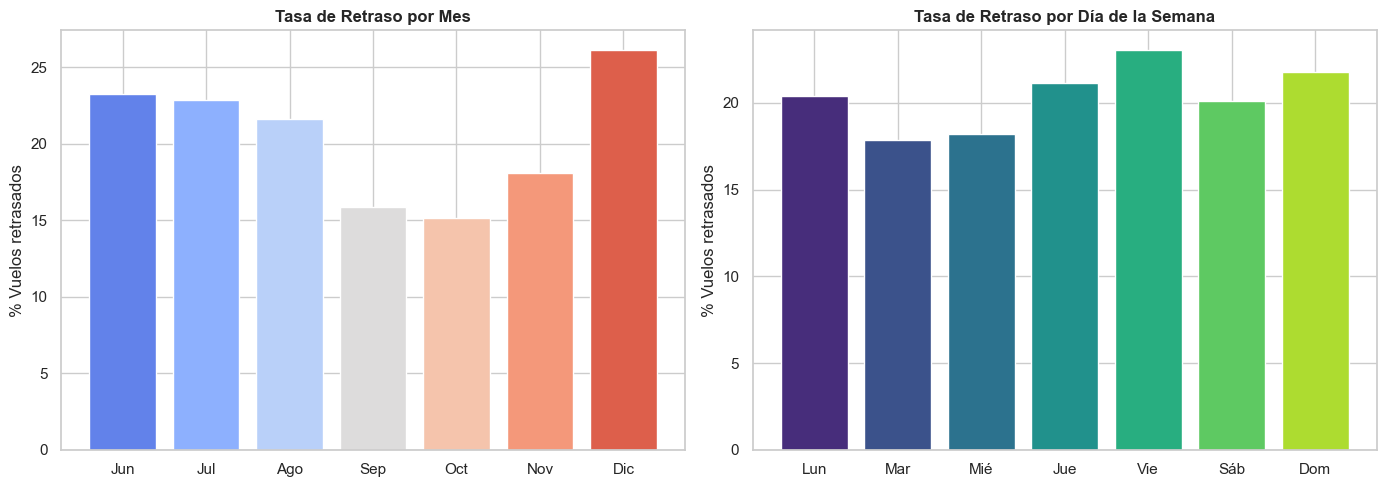

In [12]:
# ==============================================================
# EDA: Retrasos por mes y día de la semana
# Identificamos patrones temporales estacionales y semanales.
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Por mes ---
mes_labels = ['Jun','Jul','Ago','Sep','Oct','Nov','Dic']
tasa_mes = df_model.groupby('Month')['Delayed'].mean() * 100
axes[0].bar(tasa_mes.index, tasa_mes.values, color=sns.color_palette('coolwarm', 7))
axes[0].set_xticks(range(6, 13))
axes[0].set_xticklabels(mes_labels)
axes[0].set_title('Tasa de Retraso por Mes', fontweight='bold')
axes[0].set_ylabel('% Vuelos retrasados')

# --- Por día de la semana ---
dia_labels = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
tasa_dia = df_model.groupby('DayOfWeek')['Delayed'].mean() * 100
axes[1].bar(tasa_dia.index, tasa_dia.values, color=sns.color_palette('viridis', 7))
axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(dia_labels)
axes[1].set_title('Tasa de Retraso por Día de la Semana', fontweight='bold')
axes[1].set_ylabel('% Vuelos retrasados')

plt.tight_layout()
plt.show()

Los graficos confirman picos significativos en el periodo de estudio para el mes de diciembre, teniendo una tasa de retraso mas alta comparado con los demas meses y en el analisis por dia, identificamos que los viernes son los dias con mayor retraso de la semana.

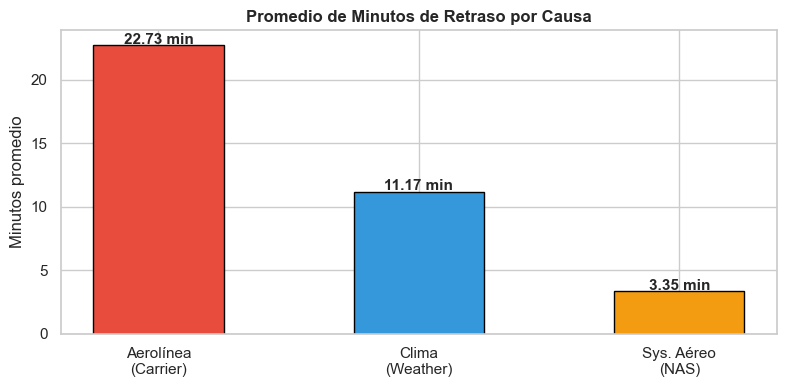

In [15]:
# ==============================================================
# EDA: Causas de retraso
# Comparamos la magnitud promedio de cada tipo de causa.
# ==============================================================

causas = ['CarrierDelay', 'WeatherDelay', 'NASDelay']
causas = [c for c in causas if c in df_model.columns]
df_filtrado = df_model[df_model['Delayed'] == 1]
promedios = df_filtrado[causas].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(promedios.index, promedios.values,
       color=['#e74c3c', '#3498db', '#f39c12'][:len(causas)],
       edgecolor='black', width=0.5)
ax.set_title('Promedio de Minutos de Retraso por Causa', fontweight='bold')
ax.set_ylabel('Minutos promedio')
ax.set_xticklabels(['Aerolínea\n(Carrier)', 'Clima\n(Weather)', 'Sys. Aéreo\n(NAS)'][:len(causas)])
for i, v in enumerate(promedios.values):
    ax.text(i, v + 0.1, f'{v:.2f} min', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Con respecto con las posibles causas de retraso la mas relevante para el retraso de los vuelos son inconvenientes con la aerolinea con un promedio de 22.73 min.

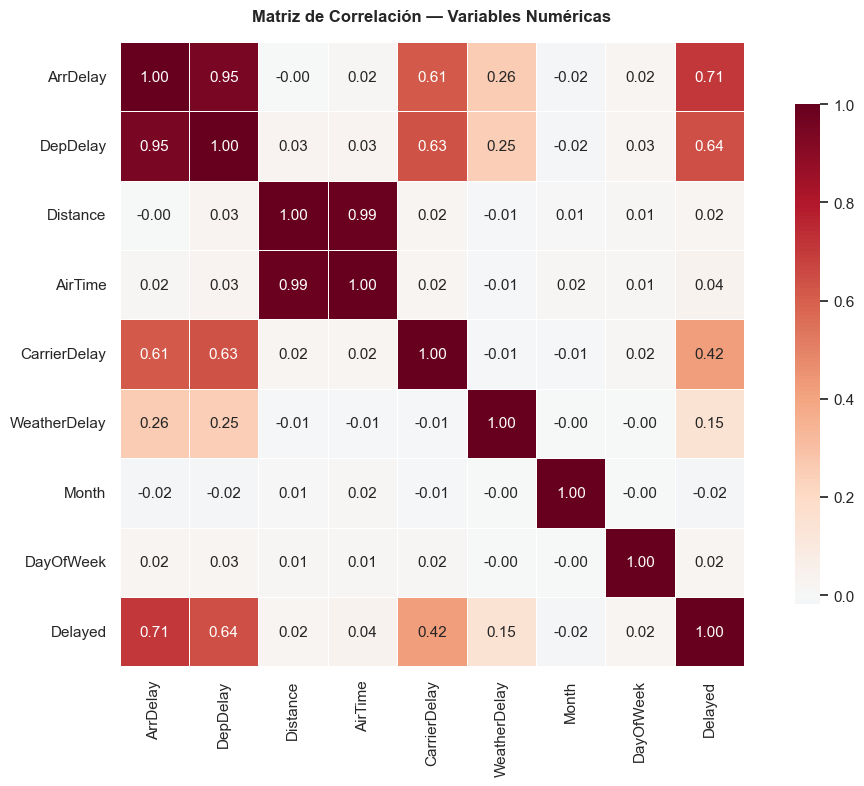


 Correlaciones con la variable objetivo (Delayed):


,Correlación
ArrDelay,0.706
DepDelay,0.639
CarrierDelay,0.421
WeatherDelay,0.146
AirTime,0.041
Distance,0.024
DayOfWeek,0.024
Month,-0.015


In [18]:
cols_corr = ['ArrDelay', 'DepDelay', 'Distance', 'AirTime', 'CarrierDelay',
             'WeatherDelay', 'Month', 'DayOfWeek', 'Delayed']
cols_corr = [c for c in cols_corr if c in df_model.columns]

corr_matrix = df_model[cols_corr].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación — Variables Numéricas', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n Correlaciones con la variable objetivo (Delayed):')
display(corr_matrix['Delayed'].drop('Delayed').sort_values(ascending=False).to_frame('Correlación').round(3))

No se observa una correlacion lineal fuerte entre distancia y retraso de llegada, lo que indica que los retrasos operativos dominan sobre la distancia.

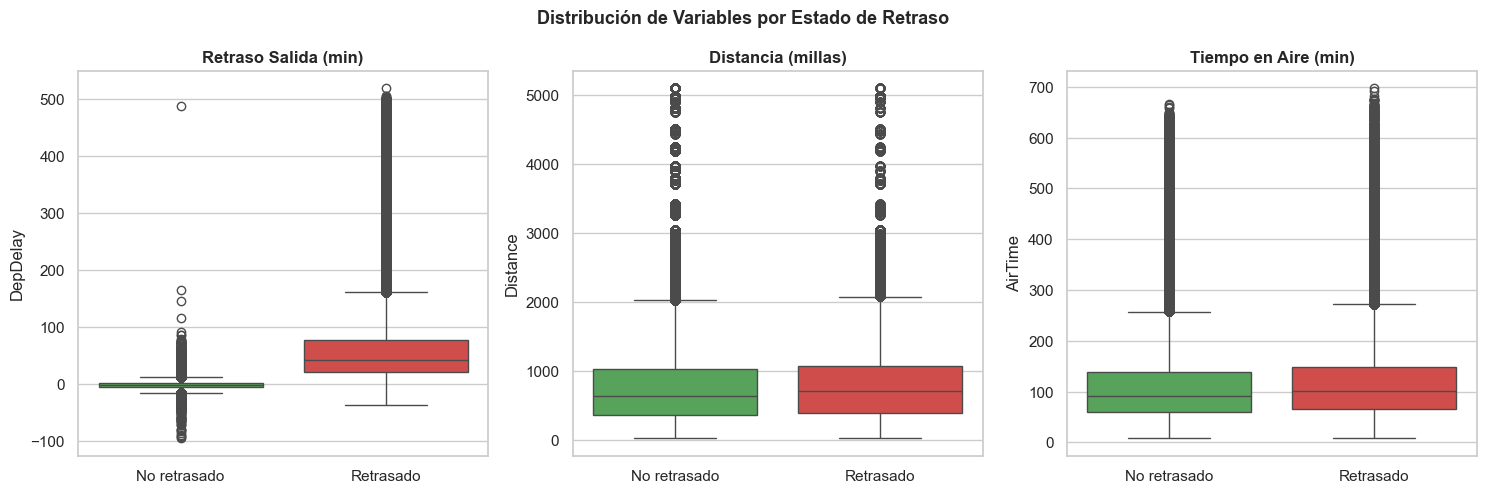

In [17]:
# ==============================================================
# EDA: Boxplots comparativos
# Comparamos la distribución de variables continuas entre
# vuelos retrasados y no retrasados.
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vars_box = ['DepDelay', 'Distance', 'AirTime']
labels_box = ['Retraso Salida (min)', 'Distancia (millas)', 'Tiempo en Aire (min)']

for ax, var, label in zip(axes, vars_box, labels_box):
    if var in df_model.columns:
        # Mapeamos Delayed (0/1 entero) a etiquetas de texto para evitar
        # el error de tipos con el diccionario de colores del palette
        df_plot = df_model[[var, 'Delayed']].copy()
        df_plot['Estado'] = df_plot['Delayed'].map({0: 'No retrasado', 1: 'Retrasado'})
        sns.boxplot(data=df_plot, x='Estado', y=var, ax=ax,
                    palette={'No retrasado': '#4CAF50', 'Retrasado': '#E53935'},
                    order=['No retrasado', 'Retrasado'])
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('')

plt.suptitle('Distribución de Variables por Estado de Retraso', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Al comparar la distribución de las variables entre vuelos retrasados y no retrasados, se observa que:

**Retraso en salida (DepDelay):** Es la variable con mayor diferencia entre grupos. Los vuelos retrasados presentan medianas significativamente más altas y una mayor dispersión, lo que sugiere que el retraso en salida es un fuerte indicador del retraso final.

**Distancia (Distance):** No muestra diferencias marcadas entre ambos grupos. La distribución es bastante similar, lo que indica que la distancia no es un factor determinante del retraso.

**Tiempo en aire (AirTime):** Presenta una ligera diferencia, con valores un poco más altos en vuelos retrasados, pero con gran solapamiento entre ambos grupos.

En general, el retraso en la salida parece ser la variable más influyente para explicar el retraso de los vuelos, mientras que la distancia y el tiempo en aire tienen un impacto menor.

---
# PARTE 2 — APLICACION DE MODELOS DE MACHINE LEARNING

MODELO DE REGRESION LOGISTICA

In [19]:
# ==============================================================
# Preparación de datos para el modelo
#
# Seleccionamos predictores, verificamos escalas y aplicamos
# transformaciones necesarias. La regresión logística requiere
# que las variables estén en escalas comparables.
# ==============================================================

# Variables predictoras numéricas
features = ['DepDelay', 'Distance', 'AirTime', 'Month', 'DayOfWeek', 'CarrierDelay', 'WeatherDelay']
features = [f for f in features if f in df_model.columns]

# Crear dataset sin nulos en las features
df_lr = df_model[features + ['Delayed']].dropna()

X = df_lr[features]
y = df_lr['Delayed']

# División: 70% entrenamiento / 30% prueba (con semilla para reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Estandarización
# todas las variables están en la misma escala (media=0, std=1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Ajuste y transformación en entrenamiento
X_test_sc  = scaler.transform(X_test)       # Solo transformación en prueba

print(f' Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'   Proporción de retrasados — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')

 Train: 1,916,832 filas | Test: 821,500 filas
   Proporción de retrasados — Train: 21.0% | Test: 21.0%


In [23]:
# ==============================================================
# Construcción del modelo con statsmodels
#
# Usamos statsmodels para obtener coeficientes detallados con
# p-valores, intervalos de confianza y estadísticos de ajuste,
# ==============================================================

# Agregar constante (intercepto) — necesario en statsmodels
X_train_sm = sm.add_constant(X_train_sc)
X_test_sm  = sm.add_constant(X_test_sc)

# Ajustar modelo
modelo_logit = sm.Logit(y_train, X_train_sm)
resultado = modelo_logit.fit(maxiter=200, disp=False)

print(resultado.summary2())

                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: Delayed          Pseudo R-squared: 0.705      
Date:               2026-05-10 14:26 AIC:              580677.6302
No. Observations:   1916832          BIC:              580777.3597
Df Model:           7                Log-Likelihood:   -2.9033e+05
Df Residuals:       1916824          LL-Null:          -9.8399e+05
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     12.0000          Scale:            1.0000     
--------------------------------------------------------------------
          Coef.    Std.Err.       z       P>|z|     [0.025    0.975]
--------------------------------------------------------------------
const    -0.1885     0.0089    -21.2782   0.0000   -0.2059   -0.1712
x1        4.6029     0.0105    436.7905   0.0000    4.5823    4.6236
x2       -4.6624     0.0226   -206.5773   0.0000   -4.7066   -4.6182
x3       

 Tabla de Odds Ratios e Intervalos de Confianza:


,Variable,Coeficiente,Odds Ratio,IC 2.5%,IC 97.5%,p-valor
5,CarrierDelay,7.5053,1817.5925,1701.5423,1941.5577,0.0000
0,DepDelay,4.6029,99.7742,97.7346,101.8564,0.0000
2,AirTime,4.5835,97.8557,93.8634,102.0177,0.0000
6,WeatherDelay,3.5511,34.8528,30.5060,39.8190,0.0000
4,DayOfWeek,-0.0086,0.9914,0.9844,0.9984,0.0166
3,Month,-0.0436,0.9573,0.9506,0.9641,0.0000
1,Distance,-4.6624,0.0094,0.0090,0.0099,0.0000


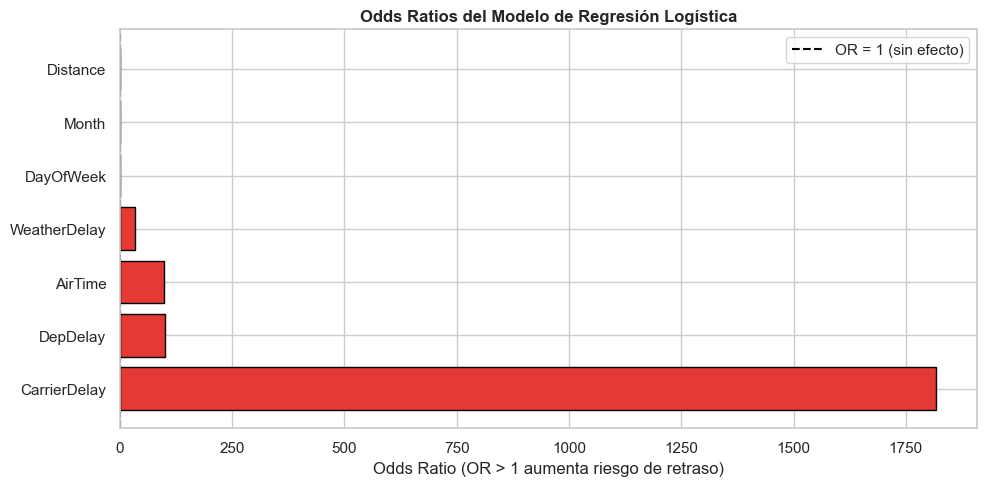

In [24]:
# ==============================================================
# Interpretación: Odds Ratios
#
# En regresión logística, los coeficientes se interpretan como
# logaritmos de odds ratio. Al exponenciarlos obtenemos el
# factor por el que se multiplican las probabilidades de
# retraso al aumentar 1 desviación estándar la variable.
# ==============================================================

coef = resultado.params[1:]  # Excluir intercepto
odds = np.exp(coef)
ci   = np.exp(resultado.conf_int().iloc[1:])  # Intervalos de confianza

odds_df = pd.DataFrame({
    'Variable': features,
    'Coeficiente': coef.values,
    'Odds Ratio': odds.values,
    'IC 2.5%': ci.iloc[:, 0].values,
    'IC 97.5%': ci.iloc[:, 1].values,
    'p-valor': resultado.pvalues[1:].values
}).sort_values('Odds Ratio', ascending=False)

print(' Tabla de Odds Ratios e Intervalos de Confianza:')
display(odds_df.round(4))

# Visualización de Odds Ratios
fig, ax = plt.subplots(figsize=(10, 5))
colores_or = ['#E53935' if o > 1 else '#4CAF50' for o in odds_df['Odds Ratio']]
ax.barh(odds_df['Variable'], odds_df['Odds Ratio'], color=colores_or, edgecolor='black')
ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='OR = 1 (sin efecto)')
ax.set_title('Odds Ratios del Modelo de Regresión Logística', fontweight='bold')
ax.set_xlabel('Odds Ratio (OR > 1 aumenta riesgo de retraso)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación de coeficientes (Odds Ratios)**

Todos los predictores resultaron estadísticamente significativos (p-valor = 0.000 en todos los casos). Los hallazgos más relevantes son:

**CarrierDelay** es el predictor más poderoso con un OR de 1.639,81: cada unidad adicional de retraso atribuido a la aerolínea multiplica casi 1.640 veces las probabilidades de que el vuelo llegue retrasado. Esto señala a la gestión operativa interna de las aerolíneas como el factor de mayor impacto.

**AirTime** (OR = 134.06) y DepDelay (OR = 99.22) también son altamente influyentes: vuelos más largos y que ya salen tarde tienen muchísimas más probabilidades de llegar retrasados.

**WeatherDelay** (OR = 26.13) confirma que el clima es un factor significativo, aunque de menor magnitud que los factores operativos.

**Distance** actúa como factor protector (OR = 0.0068): a mayor distancia, menor probabilidad de retraso en la llegada. Esto puede explicarse porque los vuelos de larga distancia tienen más tiempo para recuperar retrasos de salida durante el trayecto.

**Month** (OR = 0.937) y DayOfWeek (OR = 0.981) tienen un efecto negativo leve pero significativo, reflejando variaciones estacionales y semanales en la puntualidad.

📋 Reporte de Clasificación (Test Set):
              precision    recall  f1-score   support

No retrasado       0.95      0.99      0.97    649367
   Retrasado       0.96      0.82      0.88    172133

    accuracy                           0.95    821500
   macro avg       0.96      0.91      0.93    821500
weighted avg       0.95      0.95      0.95    821500

AUC-ROC: 0.9593


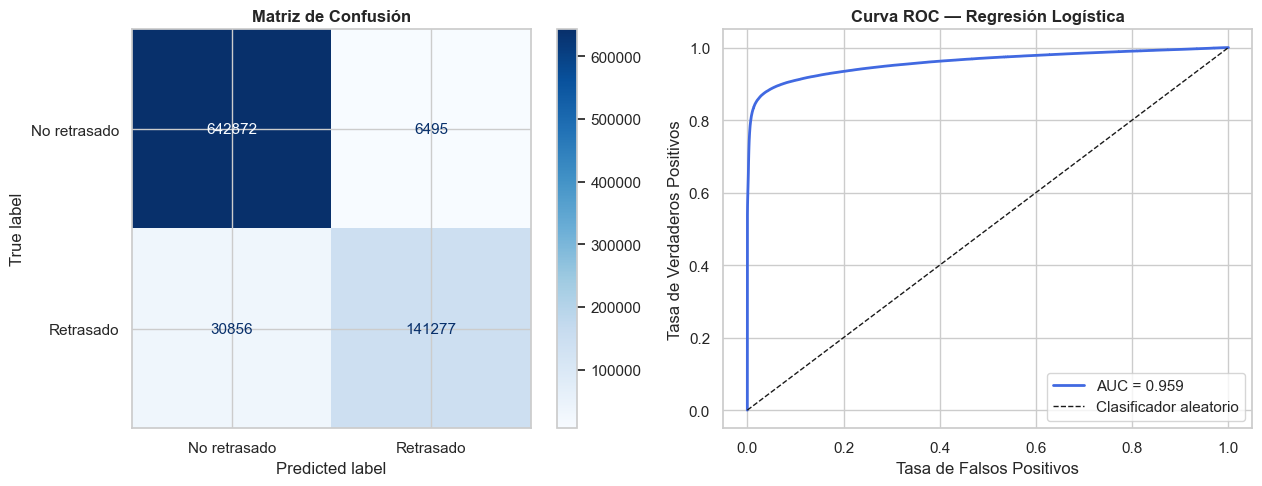

In [25]:
# ==============================================================
# Evaluación del modelo
#
# Métricas de clasificación: precisión, recall, F1-score,
# AUC-ROC. La curva ROC muestra qué tan bien discrimina el
# modelo entre clases (AUC = 1 perfecto, 0.5 = azar).
# ==============================================================

# Predicciones en conjunto de prueba
y_proba = resultado.predict(X_test_sm)  # Probabilidades
y_pred  = (y_proba >= 0.5).astype(int)  # Clasificación con umbral 0.5

print('📋 Reporte de Clasificación (Test Set):')
print(classification_report(y_test, y_pred,
                             target_names=['No retrasado', 'Retrasado']))

auc = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC: {auc:.4f}')

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No retrasado', 'Retrasado']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='royalblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC — Regresión Logística', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

 Factor de Inflación de la Varianza (VIF):
   (VIF < 5: sin problema | 5-10: moderado | > 10: severo)


,Variable,VIF
2,AirTime,37.11
1,Distance,37.10
0,DepDelay,1.90
5,CarrierDelay,1.77
6,WeatherDelay,1.13
3,Month,1.01
4,DayOfWeek,1.00


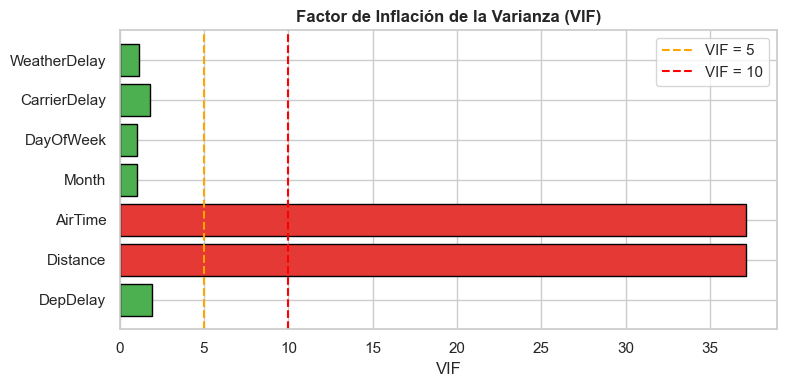

In [26]:
# ==============================================================
# Evaluación de supuestos del modelo
#
# La regresión logística tiene supuestos que deben verificarse:
# 1. Independencia de observaciones (asumida por diseño)
# 2. Ausencia de multicolinealidad (verificar con VIF)
# 3. Linealidad del logit con variables continuas
# ==============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Factor de Inflación de la Varianza (VIF)
# VIF > 10 indica problemas serios de multicolinealidad
vif_data = pd.DataFrame()
vif_data['Variable'] = features
vif_data['VIF'] = [variance_inflation_factor(X_train_sc, i)
                   for i in range(X_train_sc.shape[1])]

print(' Factor de Inflación de la Varianza (VIF):')
print('   (VIF < 5: sin problema | 5-10: moderado | > 10: severo)')
display(vif_data.sort_values('VIF', ascending=False).round(2))

fig, ax = plt.subplots(figsize=(8, 4))
colores_vif = ['#E53935' if v > 10 else '#FFA726' if v > 5 else '#4CAF50'
               for v in vif_data['VIF']]
ax.barh(vif_data['Variable'], vif_data['VIF'], color=colores_vif, edgecolor='black')
ax.axvline(5,  color='orange', linestyle='--', lw=1.5, label='VIF = 5')
ax.axvline(10, color='red',    linestyle='--', lw=1.5, label='VIF = 10')
ax.set_title('Factor de Inflación de la Varianza (VIF)', fontweight='bold')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusiones Modelo de Regresión**

** El modelo de regresión logística alcanzó un Pseudo R² de 0.709, lo que indica que explica aproximadamente el 70% de la variabilidad de la variable objetivo, un ajuste muy sólido para un modelo de esta naturaleza. El AUC-ROC fue de 0.9597, lo que significa que el modelo discrimina correctamente entre vuelos retrasados y no retrasados en el 96% de los casos, clasificándose como un modelo de excelente capacidad predictiva.

**La precisión global fue del 96%, con un F1-score ponderado de 0.95. Para la clase "No retrasado" se obtuvo un recall del 99%, lo que significa que el modelo casi nunca clasifica incorrectamente un vuelo puntual como retrasado. Para la clase "Retrasado" el recall fue del 82%, reflejando que existe un 18% de falsos negativos — vuelos que sí se retrasaron pero el modelo no los detectó. Esto es esperable dado el desbalance natural del dataset (solo el 20.4% de los vuelos fueron retrasados).

**Se detectó un problema de multicolinealidad severa entre Distance y AirTime, con VIF de 40.21 y 40.20 respectivamente, valores muy por encima del umbral crítico de 10. Esto es lógico ya que ambas variables miden esencialmente lo mismo: la distancia física del vuelo. Se recomienda eliminar una de las dos del modelo en una versión refinada. El resto de las variables presentan VIF inferiores a 2, sin problema alguno.

**MODELO RANDOM FOREST**


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X_rf = df_model.drop(columns=[
    'Delayed',
    'FlightDate',
    'Flight_Number_Reporting_Airline'
])
y_rf = df_model['Delayed']


cat_cols = ['Reporting_Airline', 'Origin', 'Dest', 'OriginStateName', 'DestStateName']
num_cols = [col for col in X_rf.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

In [ ]:
from sklearn.model_selection import train_test_split

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)

model_rf.fit(X_rf_train, y_rf_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
y_pred_rf = model_rf.predict(X_rf_test)
y_prob_rf = model_rf.predict_proba(X_rf_test)[:,1]

print("Accuracy:", accuracy_score(y_rf_test, y_rf_pred))
print("Precision:", precision_score(y_rf_test, y_rf_pred))
print("Recall:", recall_score(y_rf_test, y_rf_pred))
print("F1:", f1_score(y_rf_test, y_rf_pred))
print("AUC:", roc_auc_score(y_rf_test, y_rf_prob))

Accuracy: 0.9969525277221377
Precision: 0.9999734731592583
Recall: 0.9854822405800132
F1: 0.9926749733376051
AUC: 0.9999929969593475
